# Optimized Speaker Placement System

## Mathematical Foundation for AI & Data Science — Mini Project

### Objective

Given:

- Room length
- Room width
- Effective audio reach of a speaker
- Required minimum coverage percentage

the system determines a set of speaker positions that provides the required room coverage while attempting to minimize the number of speakers.

### Assumption

Each speaker is modeled as having a circular coverage area on a 2D floor plan.

The model does not account for:

- Walls and furniture
- Acoustic reflections
- Sound absorption
- Speaker directionality
- Speaker height
- 3D room acoustics

---


## 1. Problem Formulation

Let the rectangular room have:

- Length = $L$
- Width = $W$

The room is represented by:

$$
0 \leq x \leq L
$$

$$
0 \leq y \leq W
$$

Let the effective audio reach of a speaker be $R$.

A speaker at position:

$$
S_i = (x_i, y_i)
$$

covers a room point:

$$
P_j = (x_j, y_j)
$$

when the distance between them is less than or equal to $R$.


$$
C_{ij} =
\begin{cases}
1 & d_{ij}\le R\\
0 & d_{ij}>R
\end{cases}
$$

The optimization goal is:

1. Use as few speakers as possible.
2. Reach a user-defined minimum coverage percentage.
3. Prefer positions that provide broad and balanced room coverage.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Input Parameters

Change these values to test different rooms and speakers.

In [3]:

# ==========================
# USER INPUTS
# ==========================

ROOM_LENGTH = 12.0       # metres
ROOM_WIDTH = 8.0         # metres
SPEAKER_RADIUS = 3.0     # effective audio reach in metres

GRID_SPACING = 0.5       # distance between sampled room points
MIN_COVERAGE = 95.0      # required percentage of room points covered

# Candidate speaker positions are generated on this spacing.
# Smaller spacing -> more accurate optimization but more computation.

print(f"Room: {ROOM_LENGTH} m x {ROOM_WIDTH} m")
print(f"Speaker reach: {SPEAKER_RADIUS} m")
print(f"Required coverage: {MIN_COVERAGE}%")


Room: 12.0 m x 8.0 m
Speaker reach: 3.0 m
Required coverage: 95.0%


In [4]:

# Basic input validation

if ROOM_LENGTH <= 0 or ROOM_WIDTH <= 0:
    raise ValueError("Room dimensions must be positive.")

if SPEAKER_RADIUS <= 0:
    raise ValueError("Speaker reach must be positive.")

if GRID_SPACING <= 0:
    raise ValueError("Grid spacing must be positive.")

if not 0 < MIN_COVERAGE <= 100:
    raise ValueError("Minimum coverage must be between 0 and 100.")

print("Input validation passed.")


Input validation passed.



## 3. Representing the Room as a Mathematical Grid

Instead of testing every possible continuous point in the room, we discretize it into a finite set of points.

This converts the real-world placement problem into a computational optimization problem.

Each grid point is represented as a vector:

$$
P_j =
\begin{bmatrix}
x_j\\
y_j
\end{bmatrix}
$$



In [8]:

def create_room_grid(length, width, spacing):
    x = np.arange(0, length + spacing / 2, spacing)
    y = np.arange(0, width + spacing / 2, spacing)
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack((xx.ravel(), yy.ravel()))
    return x, y, points

x_grid, y_grid, room_points = create_room_grid(
    ROOM_LENGTH, ROOM_WIDTH, GRID_SPACING
)

print(f"Number of sampled room points: {len(room_points)}")


Number of sampled room points: 425


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


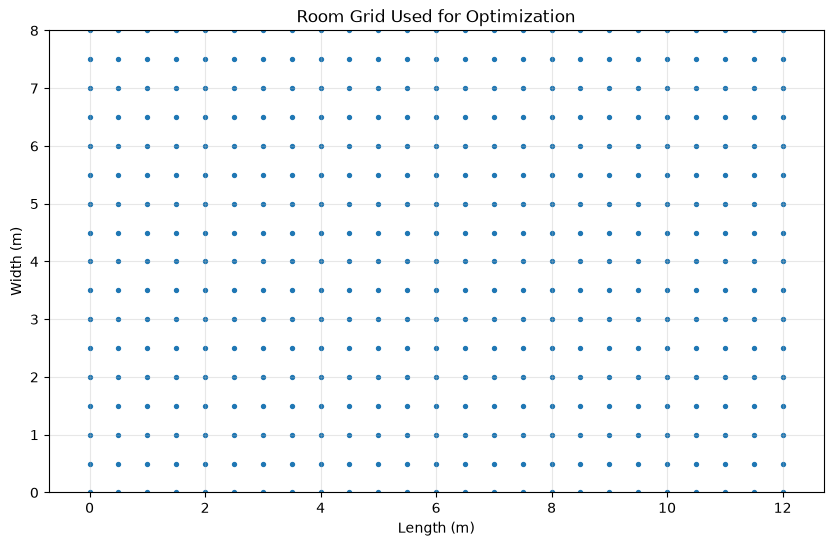

In [20]:

plt.figure(figsize=(10, 6))
plt.scatter(room_points[:, 0], room_points[:, 1], s=8)
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.title("Room Grid Used for Optimization")
plt.axis("equal")
plt.xlim(0, ROOM_LENGTH)
plt.ylim(0, ROOM_WIDTH)
plt.grid(True, alpha=0.3)
plt.show()



## 4. Generate Candidate Speaker Positions

A speaker can theoretically be placed anywhere in the room. Searching every continuous position is impossible.

Therefore, we use candidate positions on the same grid.

Each candidate is a 2D vector:

$$
S_i = 
\begin{bmatrix}
x_i\\
y_i
\end{bmatrix}
$$



In [21]:

candidate_positions = room_points.copy()

print(f"Candidate speaker positions: {len(candidate_positions)}")


Candidate speaker positions: 425



## 5. Construct the Distance Matrix

This is the main linear-algebra component.

If there are \(M\) candidate speaker positions and \(N\) room points, we create an \(M\times N\) matrix:

$$
D =
\begin{bmatrix}
d_{11} & d_{12} & \cdots & d_{1N}\\
d_{21} & d_{22} & \cdots & d_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
d_{M1} & d_{M2} & \cdots & d_{MN}
\end{bmatrix}
$$

where each element is the Euclidean distance between a candidate speaker and a room point.


In [ ]:

def calculate_distance_matrix(speaker_positions, points):
    # speaker_positions shape: (M, 2)
    # points shape: (N, 2)
    #
    # Broadcasting produces:
    # (M, 1, 2) - (1, N, 2) -> (M, N, 2)

    differences = speaker_positions[:, np.newaxis, :] - points[np.newaxis, :, :]
    distances = np.linalg.norm(differences, axis=2)
    return distances

distance_matrix = calculate_distance_matrix(
    candidate_positions,
    room_points
)

print("Distance matrix shape:", distance_matrix.shape)



## 6. Create the Binary Coverage Matrix

The distance matrix is converted into a binary coverage matrix.

$$
C_{ij}=1 \quad \text{if} \quad D_{ij}\le R
$$

This means:

- `1` → speaker covers the point
- `0` → speaker does not cover the point

This matrix allows us to turn the physical problem into a mathematical optimization problem.


In [ ]:

coverage_matrix = distance_matrix <= SPEAKER_RADIUS

print("Coverage matrix shape:", coverage_matrix.shape)
print("Coverage entries:", coverage_matrix.size)



## 7. Greedy Speaker Placement Optimization

We use a **greedy set-cover style algorithm**.

At every step:

1. Look at every unused candidate position.
2. Calculate how many currently uncovered points that speaker would cover.
3. Select the speaker that covers the largest number of uncovered points.
4. Repeat until the required coverage is reached.

This is an optimization strategy because we are trying to obtain the required coverage using as few speakers as possible.

The exact mathematical optimization problem is related to the **Set Cover Problem**, which is computationally difficult for large inputs. A greedy method gives a practical solution for this mini project.


In [ ]:

def optimize_speaker_positions(coverage_matrix, min_coverage_percent):
    num_candidates, num_points = coverage_matrix.shape

    target_points = int(np.ceil(
        (min_coverage_percent / 100) * num_points
    ))

    covered = np.zeros(num_points, dtype=bool)
    selected_indices = []

    coverage_history = []

    while covered.sum() < target_points:
        uncovered = ~covered

        # Number of new points each candidate would cover
        new_coverage = np.sum(
            coverage_matrix[:, uncovered],
            axis=1
        )

        # Prevent selecting the same candidate again
        if selected_indices:
            new_coverage[selected_indices] = -1

        best_index = int(np.argmax(new_coverage))
        best_gain = int(new_coverage[best_index])

        # No candidate can improve coverage
        if best_gain <= 0:
            break

        selected_indices.append(best_index)
        covered |= coverage_matrix[best_index]

        coverage_percent = 100 * covered.sum() / num_points

        coverage_history.append({
            "speaker_number": len(selected_indices),
            "new_points_covered": best_gain,
            "total_points_covered": int(covered.sum()),
            "coverage_percent": coverage_percent
        })

    return selected_indices, covered, coverage_history


selected_indices, covered_points, history = optimize_speaker_positions(
    coverage_matrix,
    MIN_COVERAGE
)

selected_speakers = candidate_positions[selected_indices]

actual_coverage = 100 * covered_points.mean()

print(f"Speakers required: {len(selected_speakers)}")
print(f"Achieved coverage: {actual_coverage:.2f}%")


In [ ]:

# Show optimization history

print("Optimization steps:")
print("-" * 65)

for step in history:
    print(
        f"Speaker {step['speaker_number']:2d} | "
        f"New points: {step['new_points_covered']:4d} | "
        f"Total coverage: {step['coverage_percent']:6.2f}%"
    )



## 8. Visualize the Optimized Placement

The red circles represent the theoretical effective audio reach of the selected speakers.

The blue points are room sample points covered by at least one speaker.


In [ ]:

fig, ax = plt.subplots(figsize=(12, 7))

# Covered and uncovered points
ax.scatter(
    room_points[covered_points, 0],
    room_points[covered_points, 1],
    s=10,
    label="Covered"
)

uncovered_points = ~covered_points

if np.any(uncovered_points):
    ax.scatter(
        room_points[uncovered_points, 0],
        room_points[uncovered_points, 1],
        s=10,
        marker="x",
        label="Uncovered"
    )

# Speaker positions and coverage circles
for i, (sx, sy) in enumerate(selected_speakers):
    ax.scatter(
        sx, sy,
        s=100,
        marker="*",
        label="Speaker" if i == 0 else None
    )

    circle = plt.Circle(
        (sx, sy),
        SPEAKER_RADIUS,
        fill=False,
        linewidth=2
    )
    ax.add_patch(circle)

    ax.text(
        sx,
        sy,
        f"  S{i+1}",
        fontsize=10,
        weight="bold"
    )

# Room boundary
ax.plot(
    [0, ROOM_LENGTH, ROOM_LENGTH, 0, 0],
    [0, 0, ROOM_WIDTH, ROOM_WIDTH, 0],
    linewidth=2
)

ax.set_xlabel("Room Length (m)")
ax.set_ylabel("Room Width (m)")
ax.set_title(
    f"Optimized Speaker Placement — {len(selected_speakers)} Speakers, "
    f"{actual_coverage:.2f}% Coverage"
)
ax.set_xlim(0, ROOM_LENGTH)
ax.set_ylim(0, ROOM_WIDTH)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()



## 9. Speaker Coordinates

These are the recommended coordinates measured from the bottom-left corner of the room.



In [ ]:

for i, (x, y) in enumerate(selected_speakers, start=1):
    print(f"Speaker {i}: x = {x:.2f} m, y = {y:.2f} m")



## 10. Coverage Improvement at Each Step

This graph shows how the total room coverage improves as speakers are added.


In [ ]:

if history:
    speaker_counts = [h["speaker_number"] for h in history]
    coverage_values = [h["coverage_percent"] for h in history]

    plt.figure(figsize=(9, 5))
    plt.plot(speaker_counts, coverage_values, marker="o")
    plt.axhline(
        MIN_COVERAGE,
        linestyle="--",
        label=f"Required = {MIN_COVERAGE}%"
    )

    plt.xlabel("Number of Speakers")
    plt.ylabel("Room Coverage (%)")
    plt.title("Coverage vs Number of Speakers")
    plt.xticks(speaker_counts)
    plt.ylim(0, 105)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



## 11. Mathematical Interpretation

### Euclidean Distance

For every speaker-point pair:

$$
d = \sqrt{(x_s-x_p)^2+(y_s-y_p)^2}
$$

This determines whether the point lies inside the speaker's effective range.

### Matrix Representation

Instead of calculating distances one-by-one, all distances are represented as a matrix:

$$
D_{ij}=\|S_i-P_j\|_2
$$

The subscript 2 represents the Euclidean (L2) norm.

### Binary Coverage

$$
C_{ij}=\mathbf{1}(D_{ij}\le R)
$$

The indicator function converts physical distance into a mathematical coverage decision.

### Optimization

The greedy algorithm repeatedly chooses the speaker that maximizes:

$$
\text{Gain}(S_i)
=
\sum_{j \in U} C_{ij}
$$

where \(U\) is the set of currently uncovered room points.

The algorithm stops when:

$$
\frac{\text{covered points}}
{\text{total room points}}
\times100
\ge
\text{required coverage}.
$$



## 12. Experiment With Different Room Sizes

The easiest way to demonstrate the project during the viva is to change the inputs and show that the optimal arrangement changes.

Try:

- Small room + large speaker radius
- Large room + small speaker radius
- High coverage requirement (99%)
- Lower coverage requirement (90%)
- Different grid spacing

For example:

```python
ROOM_LENGTH = 20
ROOM_WIDTH = 12
SPEAKER_RADIUS = 4
MIN_COVERAGE = 95
```

Then rerun the notebook from the parameter cell onward.



## 13. Limitations and Possible Future Improvements

This project is a mathematical placement model rather than a professional acoustic simulation.

Possible extensions:

1. **Obstacles:** Add walls, pillars, furniture, or blocked regions.
2. **Speaker direction:** Replace circular coverage with directional/elliptical coverage.
3. **3D placement:** Add speaker height and listener height.
4. **Unequal speaker power:** Give each speaker a different effective radius.
5. **Weighted areas:** Give stages, seating areas, or work areas higher importance.
6. **Noise model:** Include background noise and signal-to-noise ratio.
7. **Advanced optimization:** Compare greedy optimization with Genetic Algorithms, Particle Swarm Optimization, or Integer Linear Programming.
8. **Interactive UI:** Build a Streamlit application where the user enters room dimensions and speaker range.



# Final Result

**Input:**

- Room length
- Room width
- Speaker effective audio reach
- Required coverage percentage

**Output:**

- Minimum/near-minimum number of speakers found by the greedy optimization
- Recommended \((x,y)\) coordinates
- Percentage of room covered
- Visual floor-plan showing speaker positions and coverage regions
- Coverage improvement as speakers are added

This demonstrates a complete mathematical workflow from **coordinates → distance calculation → matrices → binary coverage → optimization → visualization**.
